In [1]:
import os
import time
import json

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog

from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    top_k_accuracy_score,
)
import joblib
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import cv2
from skimage.feature import hog

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
from joblib import Parallel, delayed


In [2]:
# ---- Configuration ----
DATA_DIR = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign"         
OUT_DIR = "ml_track_outputs"
IMG_SIZE = 100               # standardize every image to 100x100, per project requirement
SAMPLE_FRAC = 0.3          # set < 1.0 for a fast dev run, e.g. 0.2
QUICK = True                 # True = fixed hyperparameters (fast); False = grid search
FAST_SVM = True
N_JOBS = -1

os.makedirs(OUT_DIR, exist_ok=True)


In [3]:
def load_split(data_dir: str, csv_name: str) -> pd.DataFrame:
    csv_path = os.path.join(data_dir, csv_name)
    df = pd.read_csv(csv_path)
    df["AbsPath"] = df["Path"].apply(lambda p: os.path.join(data_dir, p))
    return df

train_df = load_split(DATA_DIR, "Train.csv")
test_df = load_split(DATA_DIR, "Test.csv")

if SAMPLE_FRAC < 1.0:
    train_df = train_df.groupby("ClassId", group_keys=False).apply(
        lambda g: g.sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)
    )

print(f"Train rows: {len(train_df)}")
print(f"Test rows:  {len(test_df)}")
train_df.head()


Train rows: 11763
Test rows:  12630


/tmp/ipykernel_173/967178809.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_df = train_df.groupby("ClassId", group_keys=False).apply(


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path,AbsPath
390,29,30,6,6,24,25,0,Train/0/00000_00001_00000.png,/kaggle/input/datasets/meowmeowmeowmeowmeow/gt...
532,56,54,5,5,50,49,0,Train/0/00000_00005_00022.png,/kaggle/input/datasets/meowmeowmeowmeowmeow/gt...
444,69,70,7,6,63,64,0,Train/0/00000_00002_00024.png,/kaggle/input/datasets/meowmeowmeowmeowmeow/gt...
559,60,64,5,6,55,59,0,Train/0/00000_00006_00019.png,/kaggle/input/datasets/meowmeowmeowmeowmeow/gt...
420,27,26,6,5,22,21,0,Train/0/00000_00002_00000.png,/kaggle/input/datasets/meowmeowmeowmeowmeow/gt...


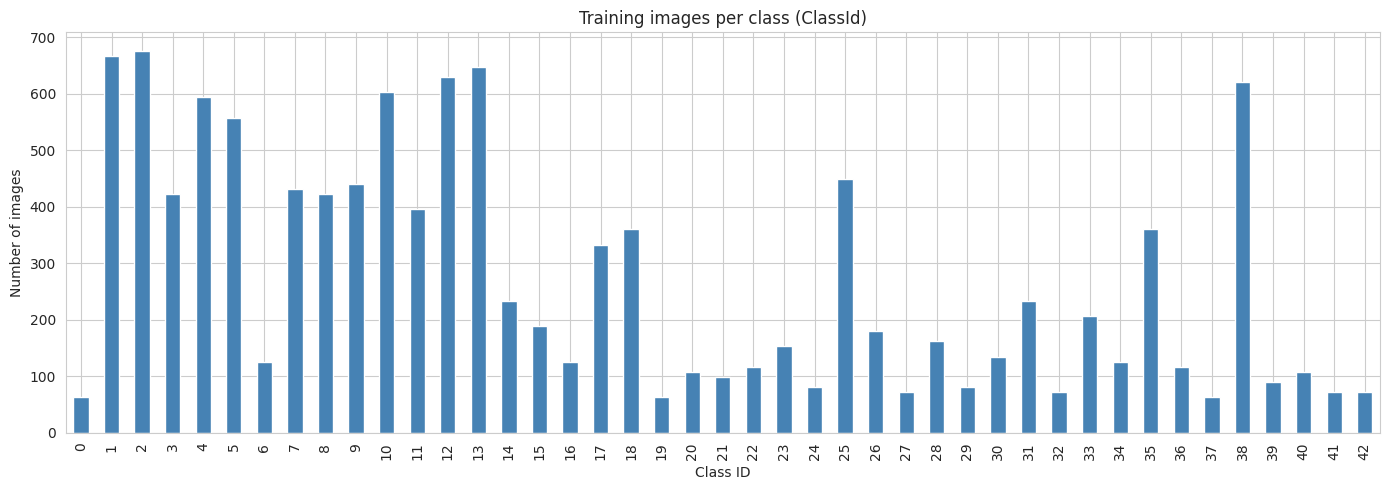

Number of classes: 43
Min class count:   63  (class 0 )
Max class count:   675  (class 2 )
Mean class count:  273.6
Imbalance ratio (max/min): 10.7


In [4]:
# Exploratory Data Analysis (EDA)
# Class distribution — checking for imbalance
class_counts = train_df["ClassId"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
class_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Training images per class (ClassId)")
ax.set_xlabel("Class ID")
ax.set_ylabel("Number of images")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "eda_class_distribution.png"), dpi=150)
plt.show()

print("Number of classes:", train_df['ClassId'].nunique())
print("Min class count:  ", class_counts.min(), " (class", class_counts.idxmin(), ")")
print("Max class count:  ", class_counts.max(), " (class", class_counts.idxmax(), ")")
print("Mean class count: ", round(class_counts.mean(), 1))
print("Imbalance ratio (max/min):", round(class_counts.max() / class_counts.min(), 1))


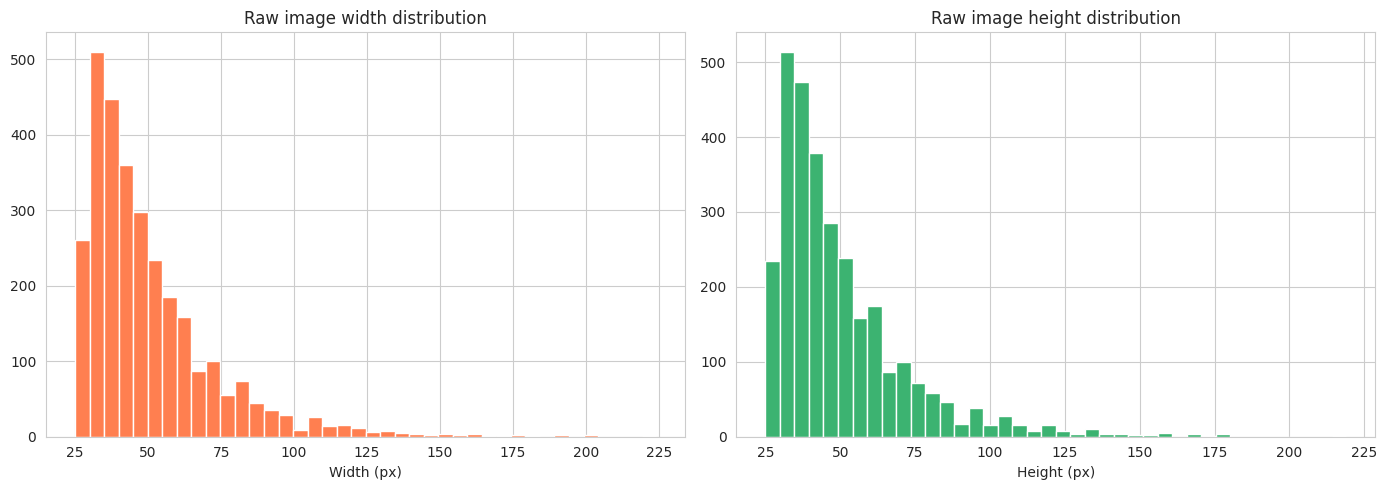

Width  — min: 25, max: 224, mean: 50.1
Height — min: 25, max: 219, mean: 49.7


In [5]:
# image size distribution
sample_for_size = train_df.sample(n=min(3000, len(train_df)), random_state=RANDOM_STATE)

widths, heights = [], []
for p in sample_for_size["AbsPath"]:
    img = cv2.imread(p, cv2.IMREAD_COLOR)
    if img is None:
        continue
    h, w = img.shape[:2]
    widths.append(w)
    heights.append(h)

widths = np.array(widths)
heights = np.array(heights)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(widths, bins=40, color="coral")
axes[0].set_title("Raw image width distribution")
axes[0].set_xlabel("Width (px)")
axes[1].hist(heights, bins=40, color="mediumseagreen")
axes[1].set_title("Raw image height distribution")
axes[1].set_xlabel("Height (px)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "eda_raw_image_sizes.png"), dpi=150)
plt.show()

print(f"Width  — min: {widths.min()}, max: {widths.max()}, mean: {widths.mean():.1f}")
print(f"Height — min: {heights.min()}, max: {heights.max()}, mean: {heights.mean():.1f}")

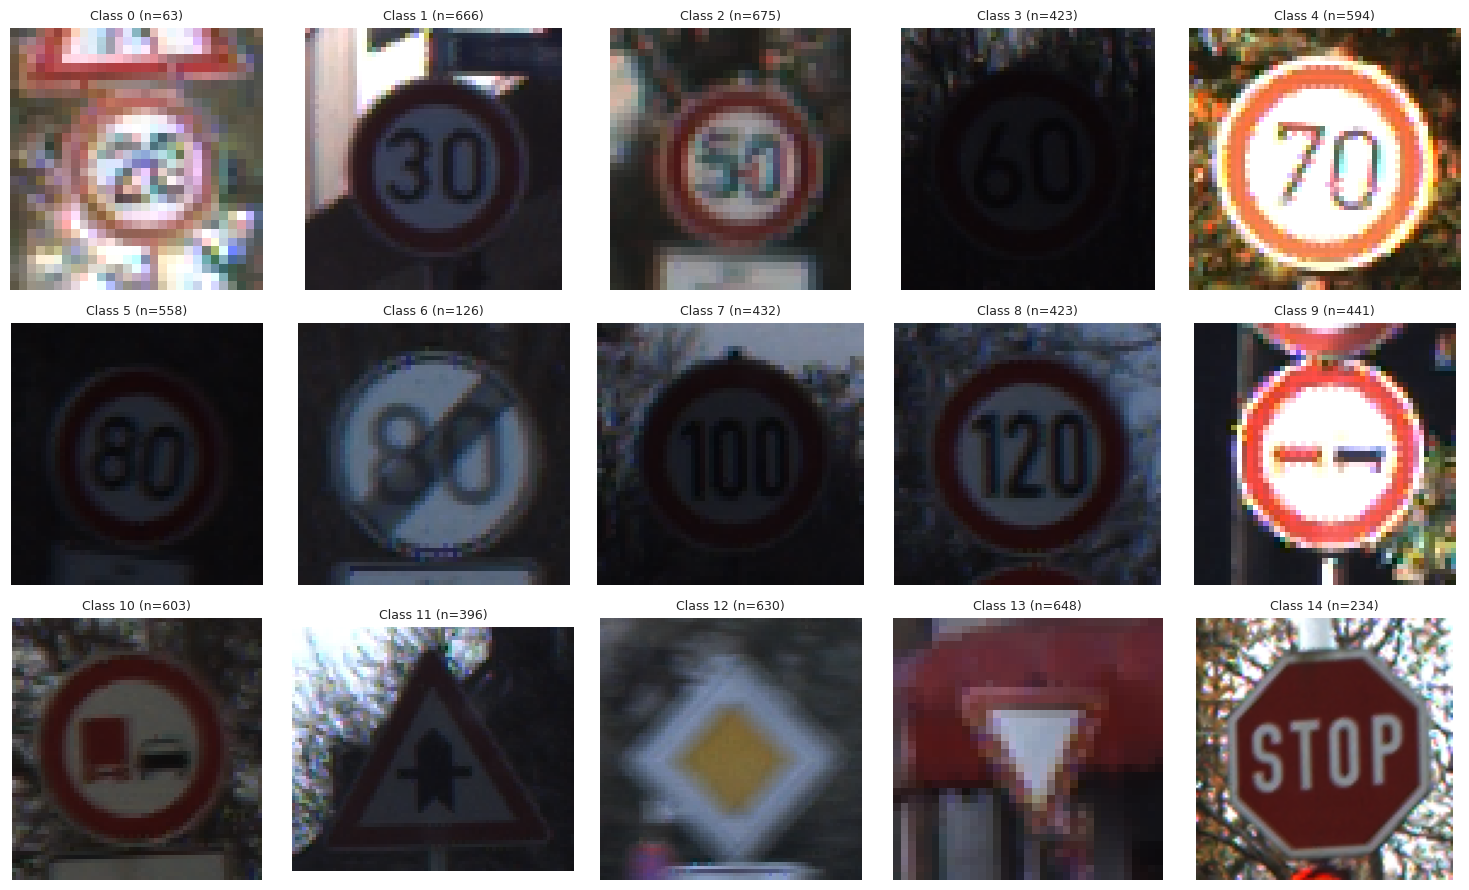

In [6]:
sample_classes = sorted(train_df["ClassId"].unique())[:15]  # first 15 classes for a quick look
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.ravel()

for ax, cls in zip(axes, sample_classes):
    row = train_df[train_df["ClassId"] == cls].iloc[0]
    img = cv2.imread(row["AbsPath"], cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"Class {cls} (n={len(train_df[train_df['ClassId']==cls])})", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "eda_sample_images.png"), dpi=150)
plt.show()

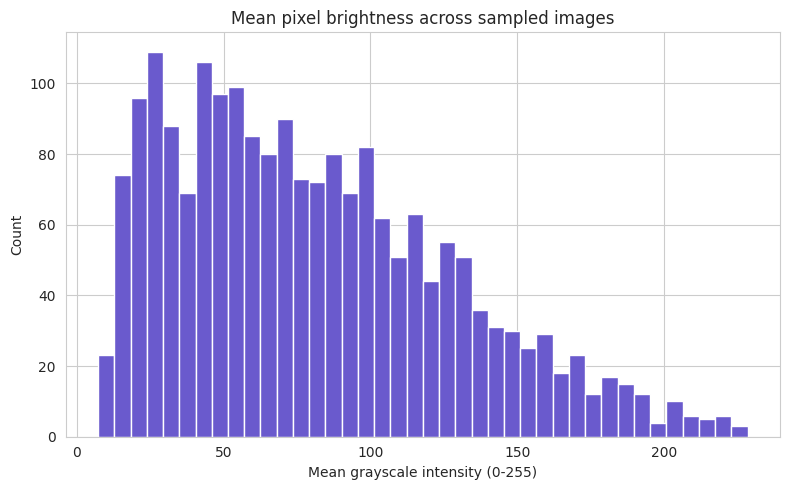

Brightness — min: 7.2, max: 228.5, std: 47.4


In [7]:
# Pixel intensity / brightness distribution
brightness_sample = train_df.sample(n=min(2000, len(train_df)), random_state=RANDOM_STATE)
brightness_values = []
for p in brightness_sample["AbsPath"]:
    img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        brightness_values.append(img.mean())

plt.figure(figsize=(8, 5))
plt.hist(brightness_values, bins=40, color="slateblue")
plt.title("Mean pixel brightness across sampled images")
plt.xlabel("Mean grayscale intensity (0-255)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "eda_brightness_distribution.png"), dpi=150)
plt.show()

print(f"Brightness — min: {np.min(brightness_values):.1f}, "
      f"max: {np.max(brightness_values):.1f}, "
      f"std: {np.std(brightness_values):.1f}")


In [8]:
# Preprocessing
def read_and_preprocess(path: str, size: int = IMG_SIZE) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)
    return gray


def build_dataset(df: pd.DataFrame, size: int = IMG_SIZE, n_jobs: int = N_JOBS):
    from joblib import Parallel, delayed
    paths = df["AbsPath"].to_numpy()
    labels = df["ClassId"].to_numpy()
    results = Parallel(n_jobs=n_jobs)(
        delayed(read_and_preprocess)(p, size) for p in paths
    )
    images = np.stack(results).astype(np.uint8)
    return images, labels

In [9]:
train_df, val_df = train_test_split(
    train_df, test_size=0.15, stratify=train_df["ClassId"], random_state=RANDOM_STATE
)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")


Train: 9998  Val: 1765  Test: 12630


In [10]:
print("Reading and preprocessing images to 100x100")
X_train_img, y_train = build_dataset(train_df)
X_val_img, y_val = build_dataset(val_df)
X_test_img, y_test = build_dataset(test_df)
print("Image array shape (train):", X_train_img.shape)

Reading and preprocessing images to 100x100
Image array shape (train): (9998, 100, 100)


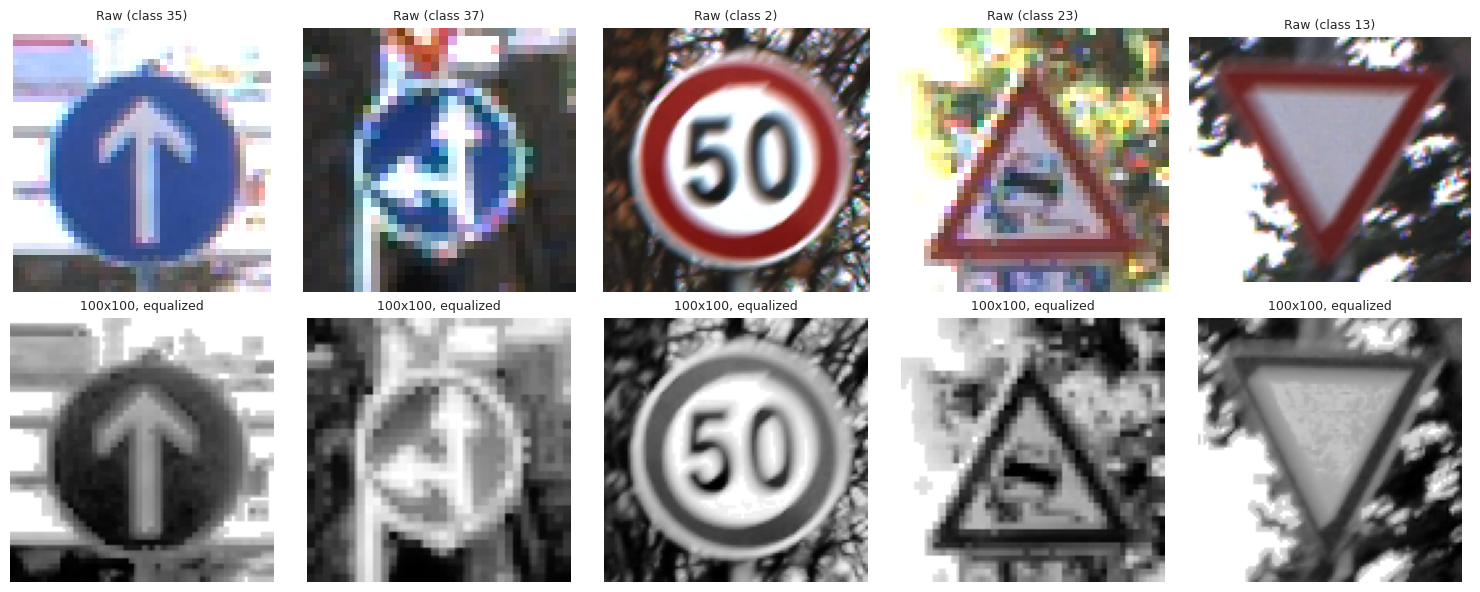

In [11]:
# Before vs After
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample_idx = np.random.choice(len(train_df), 5, replace=False)

for j, idx in enumerate(sample_idx):
    row = train_df.iloc[idx]
    raw = cv2.cvtColor(cv2.imread(row["AbsPath"], cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
    axes[0, j].imshow(raw)
    axes[0, j].set_title(f"Raw (class {row['ClassId']})", fontsize=9)
    axes[0, j].axis("off")

    axes[1, j].imshow(X_train_img[idx], cmap="gray")
    axes[1, j].set_title("100x100, equalized", fontsize=9)
    axes[1, j].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "eda_preprocessing_before_after.png"), dpi=150)
plt.show()

In [12]:
# Feature Engineering(HOG)
def _hog_single(img, pixels_per_cell):
    return hog(
        img,
        orientations=9,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True,
    )


def extract_hog_features(images: np.ndarray, n_jobs: int = N_JOBS) -> np.ndarray:
    feats = Parallel(n_jobs=n_jobs)(
        delayed(_hog_single)(img, (16, 16)) for img in images
    )
    return np.array(feats)


def _rf_single(img):
    hog_f = _hog_single(img, (16, 16))
    hist_f, _ = np.histogram(img, bins=32, range=(0, 255), density=True)
    return np.concatenate([hog_f, hist_f])


def extract_rf_features(images: np.ndarray, n_jobs: int = N_JOBS) -> np.ndarray:
    feats = Parallel(n_jobs=n_jobs)(
        delayed(_rf_single)(img) for img in images
    )
    return np.array(feats)


In [13]:
print("Extracting HOG features (SVM input)...")

t0 = time.time()
X_train_hog = extract_hog_features(X_train_img)
X_val_hog = extract_hog_features(X_val_img)
print(f"HOG feature vector length: {X_train_hog.shape[1]} "
      f"({time.time()-t0:.1f}s)")


Extracting HOG features (SVM input)...
HOG feature vector length: 900 (7.5s)


In [14]:
print("Extracting HOG + histogram features (Random Forest input)...")
t0 = time.time()
X_train_rf = extract_rf_features(X_train_img)
X_val_rf = extract_rf_features(X_val_img)
X_test_rf = extract_rf_features(X_test_img)
print(f"RF feature vector length: {X_train_rf.shape[1]}  ({time.time()-t0:.1f}s)")

Extracting HOG + histogram features (Random Forest input)...
RF feature vector length: 932  (18.2s)


In [15]:
# HOG + SVM Baseline
# Scale HOG features
scaler = StandardScaler()

X_train_hog_s = scaler.fit_transform(X_train_hog)
X_val_hog_s = scaler.transform(X_val_hog)

# Train Linear SVM
print("Training Linear SVM...")

t0 = time.time()

svm_clf = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    max_iter=3000,
    tol=1e-3,
    dual="auto"
)

svm_clf.fit(X_train_hog_s, y_train)

training_time = time.time() - t0

print(f"SVM training time: {training_time:.2f} seconds")


# Predictions
y_pred_svm_val = svm_clf.predict(X_val_hog_s)

# Accuracy
svm_val_accuracy = accuracy_score(
    y_val,
    y_pred_svm_val
)
print(f"SVM Validation Accuracy: {svm_val_accuracy:.4f}")

print("\nSVM Validation Classification Report:")

print(classification_report(
        y_val,
        y_pred_svm_val
    ))

Training Linear SVM...
SVM training time: 1064.51 seconds
SVM Validation Accuracy: 0.8969

SVM Validation Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.89      0.84         9
           1       0.86      0.83      0.85       100
           2       0.78      0.79      0.79       101
           3       0.88      0.80      0.84        64
           4       0.86      0.87      0.86        89
           5       0.74      0.68      0.71        84
           6       0.95      1.00      0.97        19
           7       0.77      0.78      0.78        65
           8       0.81      0.86      0.83        63
           9       0.90      0.95      0.93        66
          10       0.94      0.87      0.90        91
          11       0.89      0.92      0.90        59
          12       0.99      0.99      0.99        95
          13       0.99      0.99      0.99        97
          14       0.94      0.97      0.96        35
      

In [17]:
# Random Forest
print("Preparing data for Random Forest...")

# Flatten the preprocessed images
X_train_rf = X_train_img.reshape(X_train_img.shape[0], -1)
X_val_rf = X_val_img.reshape(X_val_img.shape[0], -1)

print("Training Random Forest...")

t0 = time.time()

rf_clf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)

rf_clf.fit(X_train_rf, y_train)

training_time_rf = time.time() - t0

print(f"Random Forest training time: {training_time_rf:.2f} seconds")


# Validation predictions
y_pred_rf_val = rf_clf.predict(X_val_rf)


# Validation accuracy
rf_val_accuracy = accuracy_score(
    y_val,
    y_pred_rf_val
)

print(f"Random Forest Validation Accuracy: {rf_val_accuracy:.4f}")


# Classification report
print("\nRandom Forest Validation Classification Report:")

print(
    classification_report(
        y_val,
        y_pred_rf_val
    )
)

Preparing data for Random Forest...
Training Random Forest...
Random Forest training time: 45.15 seconds
Random Forest Validation Accuracy: 0.9218

Random Forest Validation Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.78      0.88         9
           1       0.90      0.89      0.89       100
           2       0.80      0.89      0.85       101
           3       0.95      0.89      0.92        64
           4       0.86      0.94      0.90        89
           5       0.82      0.89      0.86        84
           6       1.00      1.00      1.00        19
           7       0.91      0.80      0.85        65
           8       0.90      0.89      0.90        63
           9       0.98      0.97      0.98        66
          10       0.99      0.96      0.97        91
          11       0.90      0.97      0.93        59
          12       0.92      0.96      0.94        95
          13       0.96      0.99      0.97    

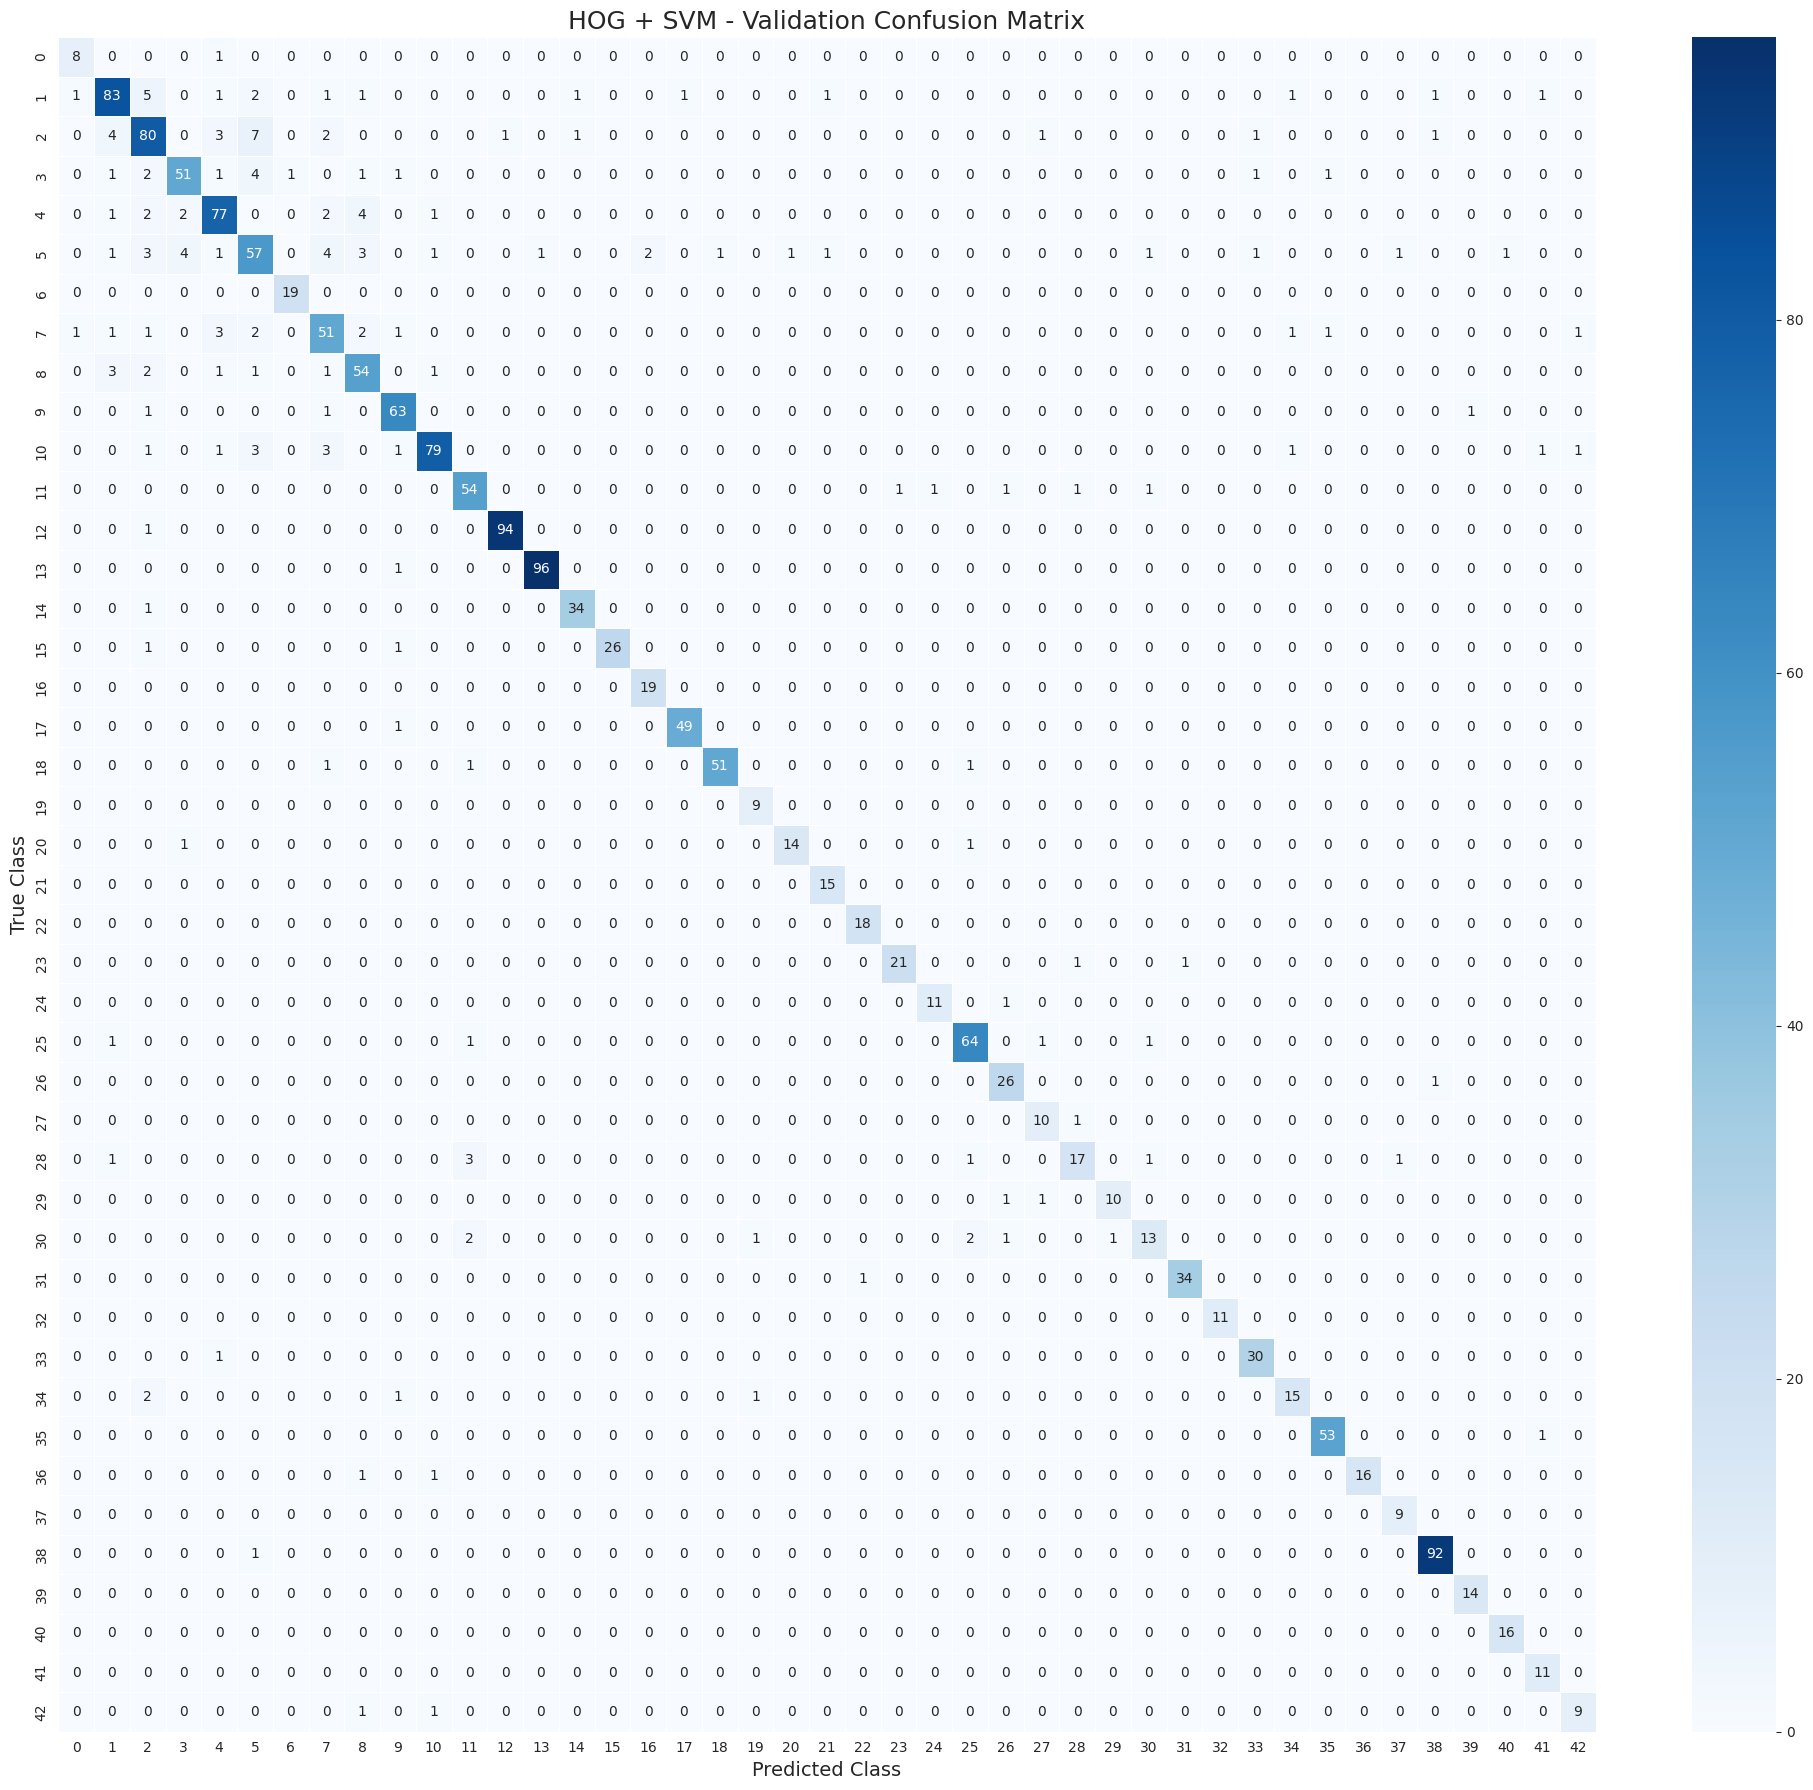

In [18]:
# Per-Class Confusion Matrix

class_labels = np.sort(np.unique(y_val))

cm_svm_val = confusion_matrix(
    y_val,
    y_pred_svm_val,
    labels=class_labels
)

plt.figure(figsize=(20, 18))

sns.heatmap(
    cm_svm_val,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5,
    linecolor="white"
)

plt.title(
    "HOG + SVM - Validation Confusion Matrix",
    fontsize=18
)

plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("True Class", fontsize=14)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUT_DIR,
        "hog_svm_validation_confusion_matrix.png"
    ),
    dpi=200,
    bbox_inches="tight"
)

plt.show()

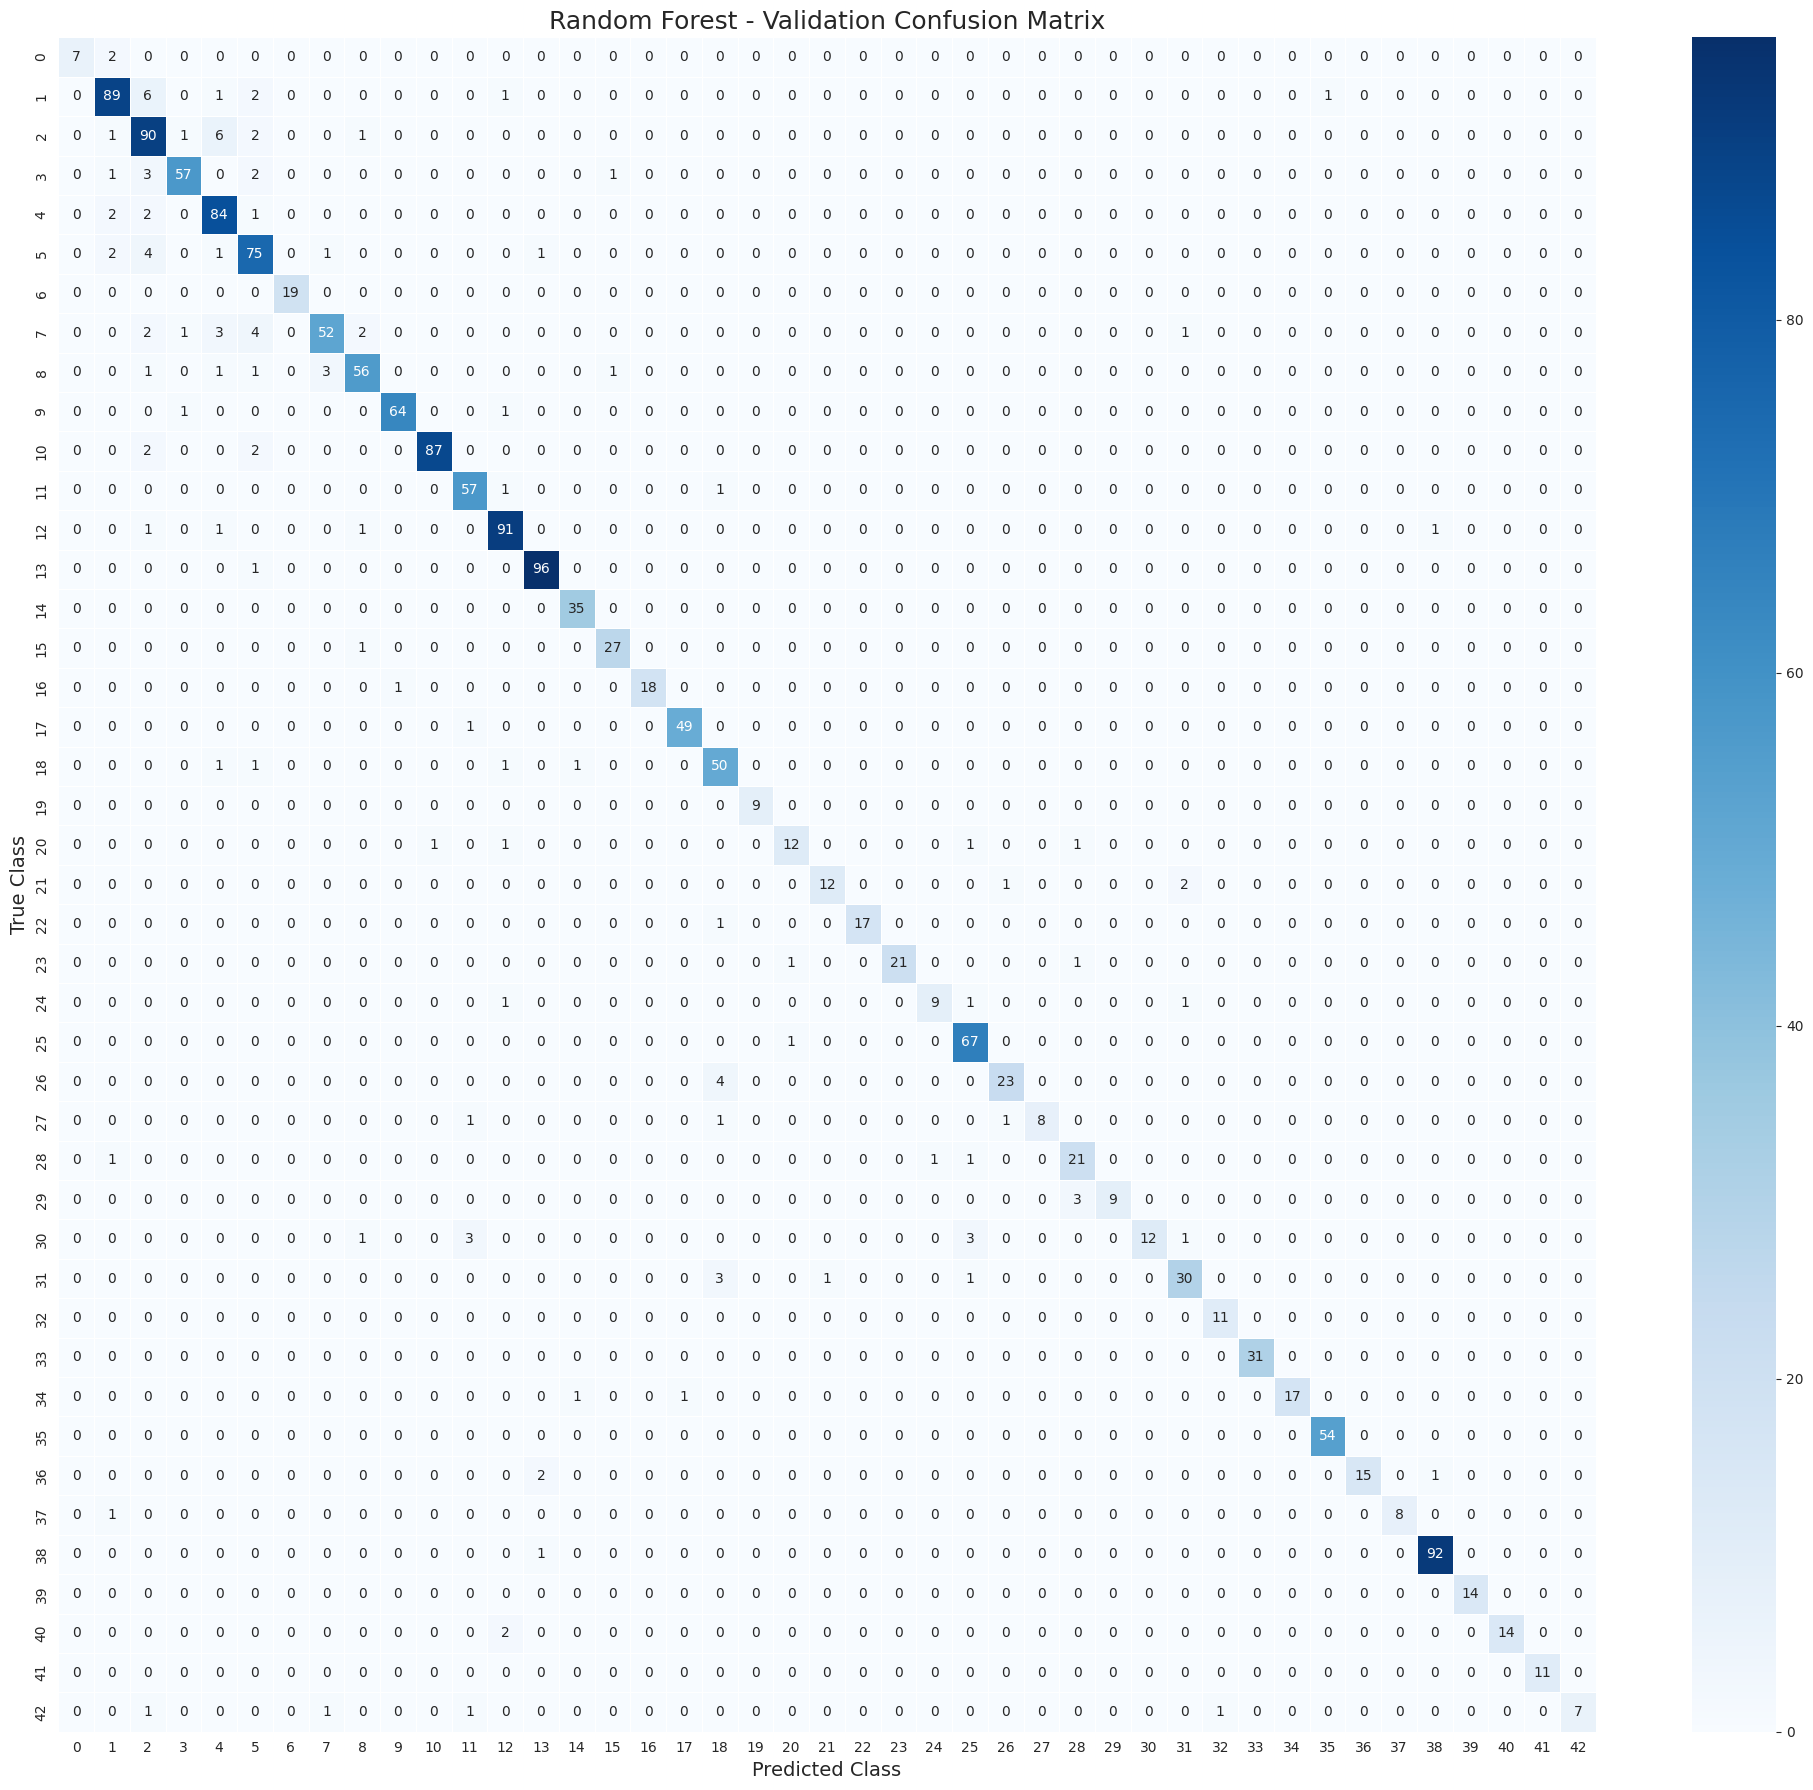

In [19]:
# Random Forest confusion matrix

cm_rf_val = confusion_matrix(
    y_val,
    y_pred_rf_val,
    labels=class_labels
)

plt.figure(figsize=(20, 18))

sns.heatmap(
    cm_rf_val,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=class_labels,
    yticklabels=class_labels,
    linewidths=0.5,
    linecolor="white"
)

plt.title(
    "Random Forest - Validation Confusion Matrix",
    fontsize=18
)

plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("True Class", fontsize=14)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUT_DIR,
        "random_forest_validation_confusion_matrix.png"
    ),
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [20]:
# Top-k prediction analysis

svm_val_scores = svm_clf.decision_function(X_val_hog_s)

print("SVM validation scores shape:", svm_val_scores.shape)
# Linear SVM
def top_k_accuracy(y_true, scores, classes, k):
    top_k_indices = np.argsort(scores, axis=1)[:, -k:]
    top_k_labels = classes[top_k_indices]

    y_true_array = np.asarray(y_true)

    correct = np.array([
        y_true_array[i] in top_k_labels[i]
        for i in range(len(y_true_array))
    ])

    return correct.mean()


for k in [1, 3, 5]:
    accuracy = top_k_accuracy(
        y_val,
        svm_val_scores,
        svm_clf.classes_,
        k
    )

    print(f"SVM Validation Top-{k} Accuracy: {accuracy:.4f}")

SVM validation scores shape: (1765, 43)
SVM Validation Top-1 Accuracy: 0.8969
SVM Validation Top-3 Accuracy: 0.9518
SVM Validation Top-5 Accuracy: 0.9592


In [21]:
# Top-K Accuracy - Random Forest
rf_val_probabilities = rf_clf.predict_proba(X_val_rf)

print(
    "RF validation probability shape:",
    rf_val_probabilities.shape
)

for k in [1, 3, 5]:

    accuracy = top_k_accuracy(
        y_val,
        rf_val_probabilities,
        rf_clf.classes_,
        k
    )

    print(f"Random Forest Validation Top-{k} Accuracy: {accuracy:.4f}")

RF validation probability shape: (1765, 43)
Random Forest Validation Top-1 Accuracy: 0.9224
Random Forest Validation Top-3 Accuracy: 0.9734
Random Forest Validation Top-5 Accuracy: 0.9847


In [22]:
# Threshold analysis
# Random Forest
rf_val_probabilities = rf_clf.predict_proba(X_val_rf)

rf_val_predictions = rf_clf.classes_[
    np.argmax(rf_val_probabilities, axis=1)
]

rf_max_probability = np.max(
    rf_val_probabilities,
    axis=1
)

thresholds = [
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

rf_threshold_results = []

y_val_array = np.asarray(y_val)

for threshold in thresholds:

    accepted = rf_max_probability >= threshold

    coverage = np.mean(accepted)

    if np.sum(accepted) > 0:
        accuracy = np.mean(
            rf_val_predictions[accepted]
            == y_val_array[accepted]
        )
    else:
        accuracy = np.nan

    rf_threshold_results.append({
        "Threshold": threshold,
        "Coverage": coverage,
        "Accuracy_on_Accepted": accuracy,
        "Rejected": np.sum(~accepted)
    })

rf_threshold_df = pd.DataFrame(rf_threshold_results)

print(rf_threshold_df)

   Threshold  Coverage  Accuracy_on_Accepted  Rejected
0        0.3  0.749008              0.994705       443
1        0.4  0.615864              0.999080       678
2        0.5  0.477620              0.998814       922
3        0.6  0.367705              1.000000      1116
4        0.7  0.251558              1.000000      1321
5        0.8  0.162040              1.000000      1479
6        0.9  0.067989              1.000000      1645


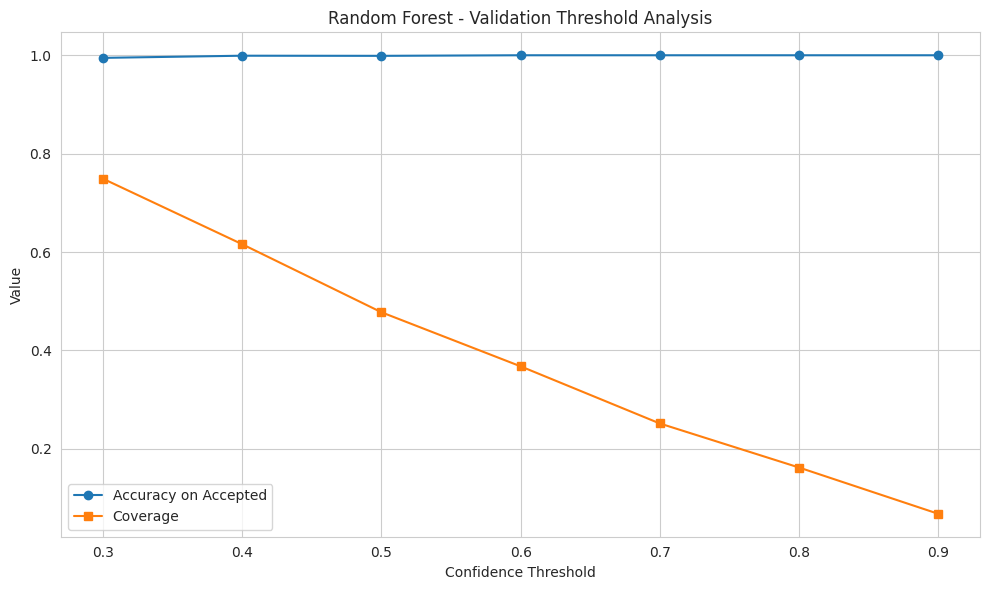

In [23]:
# Plot threshold analysis
plt.figure(figsize=(10, 6))

plt.plot(
    rf_threshold_df["Threshold"],
    rf_threshold_df["Accuracy_on_Accepted"],
    marker="o",
    label="Accuracy on Accepted"
)

plt.plot(
    rf_threshold_df["Threshold"],
    rf_threshold_df["Coverage"],
    marker="s",
    label="Coverage"
)

plt.xlabel("Confidence Threshold")
plt.ylabel("Value")
plt.title("Random Forest - Validation Threshold Analysis")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [24]:
# SVM threshold analysis

svm_val_scores = svm_clf.decision_function(X_val_hog_s)

sorted_scores = np.sort(
    svm_val_scores,
    axis=1
)

top_score = sorted_scores[:, -1]
second_score = sorted_scores[:, -2]

svm_val_margin = top_score - second_score

svm_val_predictions = svm_clf.classes_[
    np.argmax(svm_val_scores, axis=1)
]

thresholds = [
    0.05,
    0.10,
    0.20,
    0.30,
    0.50,
    0.75,
    1.00
]

svm_threshold_results = []

y_val_array = np.asarray(y_val)

for threshold in thresholds:

    accepted = svm_val_margin >= threshold

    coverage = np.mean(accepted)

    if np.sum(accepted) > 0:
        accuracy = np.mean(
            svm_val_predictions[accepted]
            == y_val_array[accepted]
        )
    else:
        accuracy = np.nan

    svm_threshold_results.append({
        "Margin Threshold": threshold,
        "Coverage": coverage,
        "Accuracy_on_Accepted": accuracy,
        "Rejected": np.sum(~accepted)
    })

svm_threshold_df = pd.DataFrame(
    svm_threshold_results
)

print(svm_threshold_df)

   Margin Threshold  Coverage  Accuracy_on_Accepted  Rejected
0              0.05  0.986402              0.904652        24
1              0.10  0.972805              0.912056        48
2              0.20  0.946176              0.923353        95
3              0.30  0.926912              0.932763       129
4              0.50  0.886686              0.943770       200
5              0.75  0.828329              0.963064       303
6              1.00  0.777337              0.968659       393


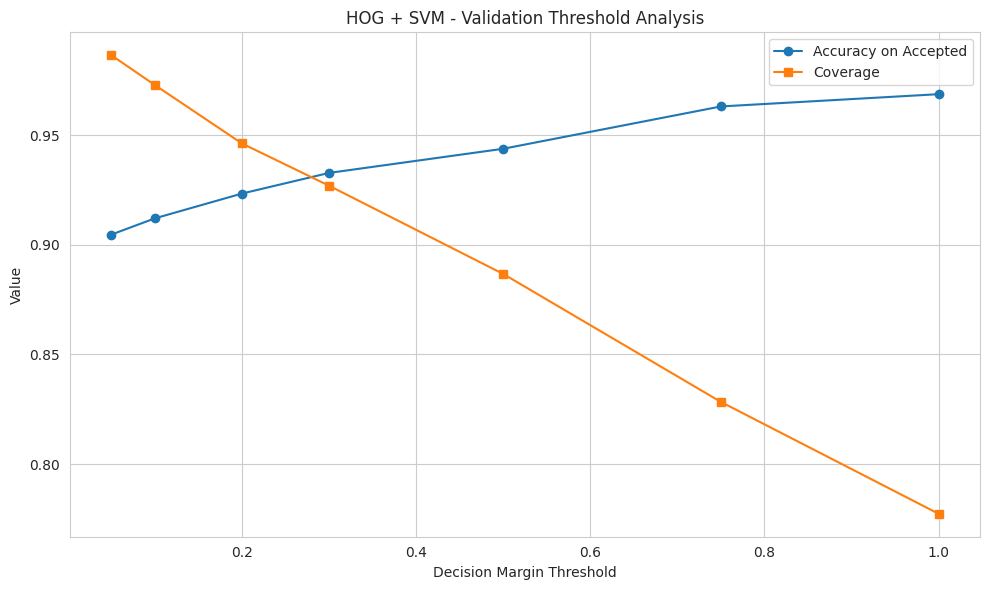

In [25]:
# Plot SVM threshold analysis
plt.figure(figsize=(10, 6))

plt.plot(
    svm_threshold_df["Margin Threshold"],
    svm_threshold_df["Accuracy_on_Accepted"],
    marker="o",
    label="Accuracy on Accepted"
)

plt.plot(
    svm_threshold_df["Margin Threshold"],
    svm_threshold_df["Coverage"],
    marker="s",
    label="Coverage"
)

plt.xlabel("Decision Margin Threshold")
plt.ylabel("Value")
plt.title("HOG + SVM - Validation Threshold Analysis")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [26]:
# Indicate Threshold
def find_threshold_for_target_accuracy(results_df, threshold_col, target_accuracy=0.98):
    """
    Returns the lowest threshold that achieves at least `target_accuracy`
    on the accepted predictions — i.e. the most permissive (highest-coverage)
    threshold that still meets your accuracy bar.
    """
    eligible = results_df[results_df["Accuracy_on_Accepted"] >= target_accuracy]
    if eligible.empty:
        print(f"No threshold in the tested range reaches {target_accuracy:.0%} accuracy. "
              f"Highest achieved: {results_df['Accuracy_on_Accepted'].max():.4f}")
        return results_df.loc[results_df["Accuracy_on_Accepted"].idxmax(), threshold_col]
    return eligible[threshold_col].min()


# --- Random Forest ---
rf_chosen_threshold = find_threshold_for_target_accuracy(
    rf_threshold_df, "Threshold", target_accuracy=0.98
)
print(f"Chosen RF confidence threshold: {rf_chosen_threshold}")

# --- SVM ---
svm_chosen_threshold = find_threshold_for_target_accuracy(
    svm_threshold_df, "Margin Threshold", target_accuracy=0.98
)
print(f"Chosen SVM margin threshold: {svm_chosen_threshold}")

Chosen RF confidence threshold: 0.3
No threshold in the tested range reaches 98% accuracy. Highest achieved: 0.9687
Chosen SVM margin threshold: 1.0


In [27]:
# Model Comparison
# Calculate metrics for SVM
svm_accuracy = accuracy_score(y_val, y_pred_svm_val)

svm_report = classification_report(
    y_val,
    y_pred_svm_val,
    output_dict=True,
    zero_division=0
)

svm_precision = svm_report["macro avg"]["precision"]
svm_recall = svm_report["macro avg"]["recall"]
svm_f1 = svm_report["macro avg"]["f1-score"]


# Calculate metrics for Random Forest
rf_accuracy = accuracy_score(y_val, y_pred_rf_val)

rf_report = classification_report(
    y_val,
    y_pred_rf_val,
    output_dict=True,
    zero_division=0
)

rf_precision = rf_report["macro avg"]["precision"]
rf_recall = rf_report["macro avg"]["recall"]
rf_f1 = rf_report["macro avg"]["f1-score"]

comparison_df = pd.DataFrame({
    "Model": [
        "HOG + Linear SVM",
        "Random Forest"
    ],
    "Accuracy": [
        svm_accuracy,
        rf_accuracy
    ],
    "Macro Precision": [
        svm_precision,
        rf_precision
    ],
    "Macro Recall": [
        svm_recall,
        rf_recall
    ],
    "Macro F1": [
        svm_f1,
        rf_f1
    ]
})

# Round values
comparison_df[
    ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
] = comparison_df[
    ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
].round(4)

print("Validation Model Comparison:")
display(comparison_df)

Validation Model Comparison:


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,HOG + Linear SVM,0.8969,0.8942,0.9105,0.9005
1,Random Forest,0.9218,0.9452,0.8966,0.9162


In [28]:

class ImagePreprocessor(BaseEstimator, TransformerMixin):
    """Raw color images (any size) -> 100x100 grayscale, histogram-equalized."""
    def __init__(self, size=100):
        self.size = size

    def fit(self, X, y=None):
        return self  # stateless — nothing to learn

    def transform(self, X):
        out = []
        for img in X:
            resized = cv2.resize(img, (self.size, self.size), interpolation=cv2.INTER_AREA)
            gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
            eq = cv2.equalizeHist(gray)
            out.append(eq)
        return np.stack(out).astype(np.uint8)


class HOGExtractor(BaseEstimator, TransformerMixin):
    """Grayscale images -> HOG feature vectors."""
    def __init__(self, pixels_per_cell=(16, 16), n_jobs=-1):
        self.pixels_per_cell = pixels_per_cell
        self.n_jobs = n_jobs

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        feats = Parallel(n_jobs=self.n_jobs)(
            delayed(hog)(
                img, orientations=9, pixels_per_cell=self.pixels_per_cell,
                cells_per_block=(2, 2), block_norm="L2-Hys", feature_vector=True,
            )
            for img in X
        )
        return np.array(feats)


class FlattenTransformer(BaseEstimator, TransformerMixin):
    """Grayscale images -> flattened raw-pixel vectors (for the RF baseline)."""
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.reshape(X.shape[0], -1)

In [29]:
svm_pipeline = Pipeline([
    ("preprocess", ImagePreprocessor(size=IMG_SIZE)),
    ("hog", HOGExtractor(pixels_per_cell=(16, 16))),
    ("scaler", scaler),      # already fitted
    ("clf", svm_clf),        # already fitted
])

rf_pipeline = Pipeline([
    ("preprocess", ImagePreprocessor(size=IMG_SIZE)),
    ("flatten", FlattenTransformer()),
    ("clf", rf_clf),         # already fitted
])

In [30]:
class ThresholdedPredictor:
    """Wraps a fitted pipeline + a confidence threshold; returns predictions
    with an explicit 'UNCERTAIN' fallback below threshold."""
    def __init__(self, pipeline, threshold, mode="proba"):
        self.pipeline = pipeline
        self.threshold = threshold
        self.mode = mode  # "proba" (RF) or "margin" (SVM decision_function)

    def predict(self, X):
        if self.mode == "proba":
            proba = self.pipeline.predict_proba(X)
            preds = self.pipeline.classes_[np.argmax(proba, axis=1)]
            confidence = proba.max(axis=1)
        else:  # margin-based, for LinearSVC
            scores = self.pipeline.decision_function(X)
            sorted_scores = np.sort(scores, axis=1)
            confidence = sorted_scores[:, -1] - sorted_scores[:, -2]
            preds = self.pipeline.classes_[np.argmax(scores, axis=1)]

        labels = np.where(confidence >= self.threshold, preds.astype(str), "UNCERTAIN")
        return labels, confidence


rf_predictor = ThresholdedPredictor(rf_pipeline, threshold=rf_chosen_threshold, mode="proba")
svm_predictor = ThresholdedPredictor(svm_pipeline, threshold=svm_chosen_threshold, mode="margin")

In [31]:
import joblib

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)
svm_path = os.path.join(MODEL_DIR, "svm_model.joblib")
rf_path = os.path.join(MODEL_DIR, "random_forest_model.joblib")

joblib.dump(
    {
        "model": svm_pipeline,
        "threshold": float(svm_chosen_threshold),
        "img_size": IMG_SIZE,
    },
    svm_path,
    compress=3,
)
joblib.dump(
    {
        "model": rf_pipeline,
        "threshold": float(rf_chosen_threshold),
        "img_size": IMG_SIZE,
    },
    rf_path,
    compress=3,
)

print(f"Saved SVM pipeline: {svm_path}")
print(f"Saved Random Forest pipeline: {rf_path}")
print(f"SVM threshold (metadata): {svm_chosen_threshold}")
print(f"RF threshold (metadata): {rf_chosen_threshold}")

Saved SVM pipeline: models/svm_model.joblib
Saved Random Forest pipeline: models/random_forest_model.joblib
SVM threshold (metadata): 1.0
RF threshold (metadata): 0.3
